In [ ]:
!pip install transformers torch scikit-learn pandas numpy -q

import json
import re
import pandas as pd
import numpy as np
import torch

from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import f1_score, precision_score, recall_score

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
def load_jsonl(path):
    with open(path, "r", encoding="utf-8") as f:
        return [json.loads(line) for line in f]

train_data = load_jsonl("/content/drive/MyDrive/ILSI_DATA/train.jsonl")
dev_data   = load_jsonl("/content/drive/MyDrive/ILSI_DATA/dev.jsonl")
test_data  = load_jsonl("/content/drive/MyDrive/ILSI_DATA/test.jsonl")

print("Train:", len(train_data))
print("Dev:", len(dev_data))
print("Test:", len(test_data))

Train: 42835
Dev: 10200
Test: 13039


In [ ]:
def clean_ipc_labels(label_list):
    cleaned = []
    for label in label_list:
        match = re.search(r'Section\s+(\d+[A-Z]?)', label)
        if match:
            cleaned.append(match.group(1))
    return cleaned


def normalize_text(text):
    if isinstance(text, list):
        return " ".join(text)
    return str(text)


def build_dataframe(data):
    rows = []
    for item in data:
        rows.append({
            "text": normalize_text(item["text"]),
            "labels": clean_ipc_labels(item["labels"])
        })
    return pd.DataFrame(rows)

train_df = build_dataframe(train_data)
dev_df = build_dataframe(dev_data)
test_df = build_dataframe(test_data)

train_df = train_df[train_df["labels"].map(len) > 0]
dev_df = dev_df[dev_df["labels"].map(len) > 0]
test_df = test_df[test_df["labels"].map(len) > 0]

print("After cleaning:")
print("Train:", len(train_df))

After cleaning:
Train: 42835


In [ ]:
mlb = MultiLabelBinarizer()

mlb.fit(train_df["labels"])

print("Total IPC sections:", len(mlb.classes_))

Total IPC sections: 98


In [ ]:
MODEL_NAME = "nlpaueb/legal-bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [ ]:
class IPCDataset(torch.utils.data.Dataset):
    def __init__(self, df, tokenizer, mlb):
        self.texts = df["text"].tolist()
        self.labels = torch.tensor(
            mlb.transform(df["labels"]),
            dtype=torch.float32
        )
        self.tokenizer = tokenizer

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
        self.texts[idx],
        truncation=True,
        padding="max_length",
        max_length=512,
        return_tensors="pt",
        return_token_type_ids=False
    )

        item = {k: v.squeeze(0) for k, v in encoding.items()}
        item["labels"] = self.labels[idx]
        return item

In [ ]:
train_dataset = IPCDataset(train_df, tokenizer, mlb)
dev_dataset = IPCDataset(dev_df, tokenizer, mlb)
test_dataset = IPCDataset(test_df, tokenizer, mlb)

In [ ]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(mlb.classes_),
    problem_type="multi_label_classification"
).to(device)

pytorch_model.bin:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: nlpaueb/legal-bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were new

In [ ]:
model.gradient_checkpointing_enable()

In [ ]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    probs = torch.sigmoid(torch.tensor(logits))
    preds = (probs > 0.5).int().numpy()

    f1 = f1_score(labels, preds, average="micro", zero_division=0)
    precision = precision_score(labels, preds, average="micro", zero_division=0)
    recall = recall_score(labels, preds, average="micro", zero_division=0)

    return {
        "f1_micro": f1,
        "precision": precision,
        "recall": recall
    }

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

SAVE_PATH = "/content/drive/MyDrive/ILSI_IPC_MODEL"

os.makedirs(SAVE_PATH, exist_ok=True)

In [ ]:
training_args = TrainingArguments(
    output_dir=SAVE_PATH,
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=1,
    dataloader_num_workers=2,
    learning_rate=1e-5,
    weight_decay=0.01,
    warmup_steps=500,
    fp16=True,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,
    load_best_model_at_end=True,
    report_to="none"
)

In [ ]:
model.gradient_checkpointing_enable()

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=dev_dataset,
    compute_metrics=compute_metrics
)

trainer.train()

Epoch,Training Loss,Validation Loss,F1 Micro,Precision,Recall
1,0.115511,0.115707,0.305868,0.818192,0.188091
2,0.096970,0.100507,0.480700,0.833292,0.337776
3,0.090085,0.096964,0.512180,0.833314,0.369707


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=16065, training_loss=0.11792721607363785, metrics={'train_runtime': 5066.4661, 'train_samples_per_second': 25.364, 'train_steps_per_second': 3.171, 'total_flos': 3.384022947462144e+16, 'train_loss': 0.11792721607363785, 'epoch': 3.0})

In [ ]:
trainer.save_model(SAVE_PATH)
tokenizer.save_pretrained(SAVE_PATH)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('/content/drive/MyDrive/ILSI_IPC_MODEL/tokenizer_config.json',
 '/content/drive/MyDrive/ILSI_IPC_MODEL/tokenizer.json')

In [ ]:
import pickle

with open(f"{SAVE_PATH}/mlb.pkl", "wb") as f:
    pickle.dump(mlb, f)

In [ ]:
print("ILSI Test Results:")
print(trainer.evaluate(test_dataset))

ILSI Test Results:


{'eval_loss': 0.09773267060518265, 'eval_f1_micro': 0.5051016914332671, 'eval_precision': 0.830219260726667, 'eval_recall': 0.36296354617746635, 'eval_runtime': 171.9976, 'eval_samples_per_second': 75.809, 'eval_steps_per_second': 9.477, 'epoch': 3.0}


In [ ]:
model.gradient_checkpointing_enable()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import torch
import pickle
from transformers import AutoModelForSequenceClassification, AutoTokenizer

MODEL_PATH = "/content/drive/MyDrive/ILSI_IPC_MODEL"

model = AutoModelForSequenceClassification.from_pretrained(MODEL_PATH)
tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)

with open(f"{MODEL_PATH}/mlb.pkl", "rb") as f:
    mlb = pickle.load(f)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

print("Model loaded successfully.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
!ls drive/MyDrive/ILSI_DATA/dev.jsonl

drive/MyDrive/ILSI_DATA/dev.jsonl


In [ ]:
import json
import re
import pandas as pd
import torch

def load_jsonl(path):
    with open(path, "r", encoding="utf-8") as f:
        return [json.loads(line) for line in f]

test_data = load_jsonl("/content/drive/MyDrive/ILSI_DATA/test.jsonl")

def clean_ipc_labels(label_list):
    cleaned = []
    for label in label_list:
        match = re.search(r'Section\s+(\d+[A-Z]?)', label)
        if match:
            cleaned.append(match.group(1))
    return cleaned

def normalize_text(text):
    if isinstance(text, list):
        return " ".join(text)
    return str(text)

def build_dataframe(data):
    rows = []
    for item in data:
        rows.append({
            "text": normalize_text(item["text"]),
            "labels": clean_ipc_labels(item["labels"])
        })
    return pd.DataFrame(rows)

test_df = build_dataframe(test_data)
test_df = test_df[test_df["labels"].map(len) > 0]

print("Test samples:", len(test_df))

Test samples: 13039


In [ ]:
import json
import pandas as pd
import re

def load_jsonl(path):
    with open(path, "r", encoding="utf-8") as f:
        return [json.loads(line) for line in f]

dev_data = load_jsonl("/content/drive/MyDrive/ILSI_DATA/dev.jsonl")

def clean_ipc_labels(label_list):
    cleaned = []
    for label in label_list:
        match = re.search(r'Section\s+(\d+[A-Z]?)', label)
        if match:
            cleaned.append(match.group(1))
    return cleaned

def normalize_text(text):
    if isinstance(text, list):
        return " ".join(text)
    return str(text)

dev_df = pd.DataFrame({
    "text": [normalize_text(x["text"]) for x in dev_data],
    "labels": [clean_ipc_labels(x["labels"]) for x in dev_data]
})

dev_df = dev_df[dev_df["labels"].map(len) > 0]

dev_df["labels"] = dev_df["labels"].apply(
    lambda x: [l for l in x if l in mlb.classes_]
)

dev_df = dev_df[dev_df["labels"].map(len) > 0]

print("Dev samples:", len(dev_df))

Dev samples: 10200


In [ ]:
class IPCDataset(torch.utils.data.Dataset):
    def __init__(self, df, tokenizer, mlb):
        self.texts = df["text"].tolist()
        self.labels = torch.tensor(
            mlb.transform(df["labels"]),
            dtype=torch.float32
        )
        self.tokenizer = tokenizer

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding="max_length",
            max_length=256,
            return_tensors="pt",
            return_token_type_ids=False
        )

        item = {k: v.squeeze(0) for k, v in encoding.items()}
        item["labels"] = self.labels[idx]
        return item

In [ ]:
test_dataset = IPCDataset(test_df, tokenizer, mlb)

In [ ]:
dev_dataset = IPCDataset(dev_df, tokenizer, mlb)

In [ ]:
from sklearn.metrics import f1_score
import numpy as np

def get_per_class_thresholds(model, dataset):

    device = next(model.parameters()).device

    all_probs = []
    all_labels = []

    loader = torch.utils.data.DataLoader(dataset, batch_size=8)

    model.eval()

    with torch.no_grad():
        for batch in loader:

            labels = batch["labels"].detach().cpu().numpy()

            inputs = {k: v.to(device) for k, v in batch.items() if k != "labels"}

            outputs = model(**inputs)
            probs = torch.sigmoid(outputs.logits).cpu().numpy()

            all_probs.append(probs)
            all_labels.append(labels)

    ...

best_threshold = get_per_class_thresholds(model, dev_dataset)

In [ ]:
from sklearn.metrics import f1_score, precision_score, recall_score
import numpy as np

def evaluate_dataset(model, dataset, threshold):

    all_probs = []
    all_labels = []

    loader = torch.utils.data.DataLoader(dataset, batch_size=8)

    model.eval()

    with torch.no_grad():
        for batch in loader:
            labels = batch["labels"].numpy()
            inputs = {k: v.to(device) for k, v in batch.items() if k != "labels"}

            outputs = model(**inputs)
            probs = torch.sigmoid(outputs.logits).cpu().numpy()

            all_probs.append(probs)
            all_labels.append(labels)

    all_probs = np.vstack(all_probs)
    all_labels = np.vstack(all_labels)

    preds = (all_probs > threshold).astype(int)

    f1 = f1_score(all_labels, preds, average="micro", zero_division=0)
    precision = precision_score(all_labels, preds, average="micro", zero_division=0)
    recall = recall_score(all_labels, preds, average="micro", zero_division=0)

    print("F1_micro:", round(f1,4))
    print("Precision:", round(precision,4))
    print("Recall:", round(recall,4))

    return f1


In [ ]:
print("ILSI TEST RESULTS (Optimized Threshold)")
evaluate_dataset(model, test_dataset, threshold=0.3102)

ILSI TEST RESULTS (Optimized Threshold)
F1_micro: 0.5181
Precision: 0.657
Recall: 0.4276


0.51808751639442

In [ ]:
def explain_with_gradients(text, target_section):

    model.eval()

    text = expand_short_query(text)

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=256
    )

    inputs = {k: v.to(device) for k, v in inputs.items()}

    embeddings = model.get_input_embeddings()(inputs["input_ids"])
    embeddings.retain_grad()
    embeddings.requires_grad_(True)

    outputs = model(
        inputs_embeds=embeddings,
        attention_mask=inputs["attention_mask"]
    )

    probs = torch.sigmoid(outputs.logits)

    section_index = list(mlb.classes_).index(target_section)

    score = probs[0, section_index]

    model.zero_grad()
    score.backward()

    grads = embeddings.grad.abs().sum(dim=2).squeeze()

    tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])

    token_importance = list(zip(tokens, grads.detach().cpu().numpy()))
    token_importance = sorted(token_importance, key=lambda x: x[1], reverse=True)

    important_tokens = [tok for tok, _ in token_importance[:5]]

    return important_tokens

In [ ]:
def expand_short_query(text):
    text = text.lower().strip()

    if len(text.split()) <= 3:

        templates = {
            "rape": "The accused forcibly committed rape against the victim.",
            "murder": "The accused intentionally killed the victim with a weapon.",
            "kidnap": "The accused kidnapped the victim unlawfully and confined them.",
            "theft": "The accused dishonestly stole property from the complainant.",
            "robbery": "The accused committed robbery using force and threat.",
        }

        return templates.get(text, f"The accused committed the offence of {text} against the victim.")

    return text

def predict_ipc(text, threshold=0.3102, top_k=5):

    text = expand_short_query(text)

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=256
    )

    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.sigmoid(outputs.logits).cpu().numpy()[0]

    predictions = []

    for i, p in enumerate(probs):
        if p > threshold:
            predictions.append((mlb.classes_[i], float(p)))

    if len(predictions) < 2:
        relaxed_threshold = threshold * 0.7
        for i, p in enumerate(probs):
            if p > relaxed_threshold:
                predictions.append((mlb.classes_[i], float(p)))

    predictions = list(set(predictions))

    predictions = sorted(predictions, key=lambda x: x[1], reverse=True)

    if len(predictions) == 0:
        top_indices = probs.argsort()[-top_k:][::-1]
        predictions = [(mlb.classes_[i], float(probs[i])) for i in top_indices]

    return predictions[:top_k]

In [ ]:
import torch
import numpy as np
from tqdm import tqdm

def get_predictions(model, dataset, threshold):

    device = next(model.parameters()).device
    loader = torch.utils.data.DataLoader(dataset, batch_size=16, shuffle=False)

    all_probs = []
    all_labels = []

    model.eval()

    with torch.no_grad():
        for batch in tqdm(loader, desc="Running Inference"):

            labels = batch["labels"].cpu().numpy()

            inputs = {
                k: v.to(device)
                for k, v in batch.items()
                if k != "labels"
            }

            outputs = model(**inputs)
            probs = torch.sigmoid(outputs.logits).cpu().numpy()

            all_probs.append(probs)
            all_labels.append(labels)

    all_probs = np.vstack(all_probs)
    all_labels = np.vstack(all_labels)

    preds = (all_probs > threshold).astype(int)

    return all_labels, preds

In [ ]:
from sklearn.metrics import multilabel_confusion_matrix

def compute_global_confusion_matrix(y_true, y_pred):

    mcm = multilabel_confusion_matrix(y_true, y_pred)

    TP = mcm[:, 1, 1].sum()
    TN = mcm[:, 0, 0].sum()
    FP = mcm[:, 0, 1].sum()
    FN = mcm[:, 1, 0].sum()

    print("\n" + "="*50)
    print("GLOBAL CONFUSION MATRIX")
    print("="*50)
    print(f"TP: {TP}")
    print(f"FP: {FP}")
    print(f"FN: {FN}")
    print(f"TN: {TN}")

    return TP, FP, FN, TN

In [ ]:
def per_class_confusion_matrix(y_true, y_pred, mlb, top_k=10):

    from sklearn.metrics import multilabel_confusion_matrix

    mcm = multilabel_confusion_matrix(y_true, y_pred)

    label_counts = y_true.sum(axis=0)
    top_indices = np.argsort(label_counts)[-top_k:][::-1]

    print("\n" + "="*70)
    print("PER-CLASS CONFUSION MATRIX (TOP IPC SECTIONS)")
    print("="*70)

    for idx in top_indices:

        tn, fp, fn, tp = mcm[idx].ravel()
        section = mlb.classes_[idx]

        precision = tp / (tp + fp + 1e-8)
        recall    = tp / (tp + fn + 1e-8)
        f1        = 2 * precision * recall / (precision + recall + 1e-8)

        print(f"\nSection {section}")
        print("-"*40)
        print(f"TP: {tp} | FP: {fp} | FN: {fn} | TN: {tn}")
        print(f"Precision: {precision:.4f}")
        print(f"Recall:    {recall:.4f}")
        print(f"F1:        {f1:.4f}")

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_global_cm(tp, fp, fn, tn):

    cm = np.array([[tn, fp],
                   [fn, tp]])

    plt.figure(figsize=(5,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=["Pred 0", "Pred 1"],
                yticklabels=["Actual 0", "Actual 1"])

    plt.title("Global Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

Running Inference: 100%|██████████| 815/815 [04:18<00:00,  3.15it/s]


GLOBAL CONFUSION MATRIX
TP (correct IPC predicted): 21726
FP (wrong IPC predicted):   11340
FN (missed IPC):            29078
TN (correct rejection):     1215678


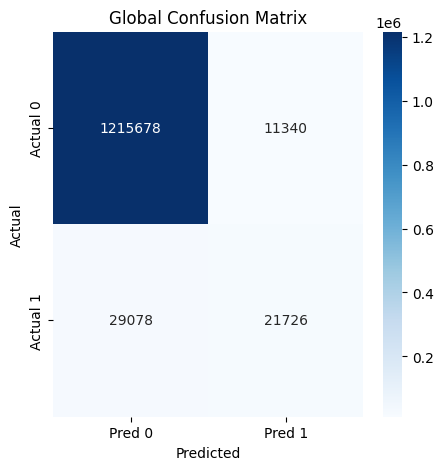


PER-CLASS CONFUSION MATRIX (TOP IPC SECTIONS)

Section 34
----------------------------------------
TP: 2397 | FP: 1035 | FN: 1337 | TN: 8270
Precision: 0.6984
Recall:    0.6419
F1:        0.6690

Section 302
----------------------------------------
TP: 2691 | FP: 852 | FN: 555 | TN: 8941
Precision: 0.7595
Recall:    0.8290
F1:        0.7928

Section 506
----------------------------------------
TP: 1613 | FP: 847 | FN: 948 | TN: 9631
Precision: 0.6557
Recall:    0.6298
F1:        0.6425

Section 323
----------------------------------------
TP: 1543 | FP: 960 | FN: 949 | TN: 9587
Precision: 0.6165
Recall:    0.6192
F1:        0.6178

Section 307
----------------------------------------
TP: 1266 | FP: 845 | FN: 959 | TN: 9969
Precision: 0.5997
Recall:    0.5690
F1:        0.5839

Section 147
----------------------------------------
TP: 778 | FP: 505 | FN: 606 | TN: 11150
Precision: 0.6064
Recall:    0.5621
F1:        0.5834

Section 294
----------------------------------------
TP: 821 | 

In [ ]:

threshold = 0.3102

# 1. Predictions
y_true, y_pred = get_predictions(model, test_dataset, threshold)

# 2. Global CM
tp, fp, fn, tn = global_confusion_matrix(y_true, y_pred)

# 3. Plot
plot_global_cm(tp, fp, fn, tn)

# 4. Per-class CM
per_class_confusion_matrix(y_true, y_pred, mlb, top_k=10)

In [ ]:
def interactive():

    print("IPC SECTION RECOMMENDER (With Explanation)")
    print("Optimized Threshold:", 0.3102)
    print("Type 'quit' to exit.\n")

    while True:
        text = input("Enter crime description: ")

        if text.lower() == "quit":
            print("Thank you")
            break

        preds = predict_ipc(text)

        if not preds:
            print("No IPC sections predicted.\n")
        else:
            print("\nPredicted IPC Sections:")

            for sec, prob in preds:
                print(f"Section {sec} → {prob*100:.2f}%")

                tokens = explain_with_gradients(text, sec)

                clean_tokens = []
                for tok in tokens:
                    if tok.startswith("##"):
                        tok = tok[2:]
                    if tok not in ["[CLS]", "[SEP]", "[PAD]"]:
                        clean_tokens.append(tok)

                print("Model focused on:", ", ".join(clean_tokens))

        print()

interactive()

IPC SECTION RECOMMENDER (With Explanation)
Optimized Threshold: 0.3102
Type 'quit' to exit.

Enter crime description: rape

Predicted IPC Sections:
Section 376 → 45.21%
Model focused on: rape, forcibl, accused, victim
Section 34 → 27.15%
Model focused on: rape, forcibl, accused, victim
Section 323 → 27.12%
Model focused on: rape, forcibl, victim, accused

Enter crime description: quit
Thank you


In [ ]:
import torch
import pickle
import numpy as np
import pandas as pd
import re

from datasets import load_dataset
from sklearn.metrics import f1_score, precision_score, recall_score
from transformers import AutoModelForSequenceClassification, AutoTokenizer

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

MODEL_PATH = "/content/drive/MyDrive/ILSI_IPC_MODEL"

model = AutoModelForSequenceClassification.from_pretrained(MODEL_PATH)
tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)

with open(f"{MODEL_PATH}/mlb.pkl", "rb") as f:
    mlb = pickle.load(f)

model.to(device)
model.eval()

print("loaded successfully.")

In [83]:

from datasets import load_dataset
import numpy as np
import pandas as pd
import re
import torch
from tqdm import tqdm
from sklearn.metrics import f1_score, precision_score, recall_score


bail_data = load_dataset("SnehaDeshmukh/IndianBailJudgments-1200", split="train")
bail_df = bail_data.to_pandas()

print("Total samples:", len(bail_df))

def extract_ipc(text):
    pattern = r'(?:Section|Sections|section|u/s|under section)\s+(\d{1,3}[A-Z]?)'
    return list(set(re.findall(pattern, text)))

bail_df["labels"] = bail_df["facts"].apply(extract_ipc)

# Keep valid labels only
bail_df = bail_df[bail_df["labels"].map(len) > 0]
bail_df["labels"] = bail_df["labels"].apply(
    lambda x: [l for l in x if l in mlb.classes_]
)
bail_df = bail_df[bail_df["labels"].map(len) > 0]

print("Valid samples:", len(bail_df))

def clean_text(text):
    if not isinstance(text, str):
        return ""
    return text.lower().strip()[:512]

bail_df["text"] = bail_df["facts"].apply(clean_text)

y_true = mlb.transform(bail_df["labels"])


device = next(model.parameters()).device

BATCH_SIZE = 16
threshold = 0.3102

texts = bail_df["text"].tolist()
all_probs = []

for i in tqdm(range(0, len(texts), BATCH_SIZE), desc="Running Bail Test"):

    batch = texts[i:i+BATCH_SIZE]

    inputs = tokenizer(
        batch,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=512
    )

    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.sigmoid(outputs.logits).cpu().numpy()

    all_probs.append(probs)

all_probs = np.vstack(all_probs)


y_pred = (all_probs > threshold).astype(int)


f1 = f1_score(y_true, y_pred, average="micro", zero_division=0)
precision = precision_score(y_true, y_pred, average="micro", zero_division=0)
recall = recall_score(y_true, y_pred, average="micro", zero_division=0)

print("\nFINAL TEST RESULTS (INDIAN BAIL)")
print("F1_micro:", round(f1, 4))
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))

Total samples: 1200
Valid samples: 156


Running Bail Test: 100%|██████████| 10/10 [00:01<00:00,  8.37it/s]



FINAL TEST RESULTS (INDIAN BAIL)
F1_micro: 0.4234
Precision: 0.3355
Recall: 0.5738


In [84]:


import random
import torch
import numpy as np

device = next(model.parameters()).device
threshold = 0.3102  # same as your test

def predict_ipc_from_text(text, threshold=0.3102, top_k=5):

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=512
    )

    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.sigmoid(outputs.logits).cpu().numpy()[0]

    # get predictions
    preds = [(mlb.classes_[i], float(probs[i]))
             for i in range(len(probs)) if probs[i] > threshold]

    # fallback if nothing predicted
    if len(preds) == 0:
        top_indices = probs.argsort()[-top_k:][::-1]
        preds = [(mlb.classes_[i], float(probs[i])) for i in top_indices]

    preds = sorted(preds, key=lambda x: x[1], reverse=True)

    return preds[:top_k]
def test_random_bail_sample(bail_df):

    sample = bail_df.sample(1).iloc[0]

    text = sample["text"]
    true_labels = sample["labels"]

    print("\n" + "="*70)
    print(" SAMPLE FROM INDIAN BAIL DATASET")
    print("="*70)

    print("\n TEXT:")
    print(text[:500], "...")

    print("\n ACTUAL IPC SECTIONS:")
    print(", ".join(true_labels))

    # prediction
    preds = predict_ipc_from_text(text)

    print("\n PREDICTED IPC SECTIONS:")
    for sec, prob in preds:
        print(f"Section {sec} → {prob*100:.2f}%")

    # overlap check
    pred_labels = [sec for sec, _ in preds]
    correct = set(pred_labels) & set(true_labels)

    print("\n MATCH ANALYSIS:")
    print(f"Correct Matches: {list(correct)}")
    print(f"Missed: {list(set(true_labels) - set(pred_labels))}")
    print(f"Extra: {list(set(pred_labels) - set(true_labels))}")

    print("="*70)

for _ in range(3):
    test_random_bail_sample(bail_df)


 SAMPLE FROM INDIAN BAIL DATASET

 TEXT:
suneshwar singh thakur, assistant manager at a cooperative society, was accused of fraudulently withdrawing money in the names of depositors and not depositing collected funds. he was arrested in august 2015. despite charges being framed in april 2016, no witness was examined for over a year. he filed for bail under section 437(6) crpc, which was initially rejected due to the gravity of charges, but later granted by the high court due to prolonged detention without trial progress. ...

 ACTUAL IPC SECTIONS:
437

 PREDICTED IPC SECTIONS:
Section 420 → 52.34%
Section 468 → 42.28%
Section 471 → 40.96%
Section 120B → 38.73%
Section 467 → 32.47%

 MATCH ANALYSIS:
Correct Matches: []
Missed: ['437']
Extra: ['467', '468', '120B', '420', '471']

 SAMPLE FROM INDIAN BAIL DATASET

 TEXT:
danish khan was arrested on 23 may 2018 for alleged robbery under sections 392 and 397 ipc. despite multiple prior criminal cases, he was acquitted in sessions trials no